<a href="https://colab.research.google.com/github/silprosa/nipe_macho/blob/main/notebooks/potholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI project

# Potholes Detection

**Updated**: June 2026
**Framework**: Fynesse (Access, Assess, Address)  
**Environment**: colab notebook

This notebook demonstrates the complete Fynesse data analysis pipeline using modern Python development practices.

### **Abstract**

Road potholes pose significant challenges to transportation infrastructure, contributing to vehicle damage, increased maintenance costs, traffic disruptions, and road safety hazards. Traditional road inspection methods rely heavily on manual surveys, which are often time-consuming, labor-intensive, and inefficient for large road networks. This project presents an AI-based pothole detection system utilizing the YOLOv8 object detection framework to automatically identify potholes from road images collected on Kenyan roads.

The system is trained on a custom annotated dataset and evaluated using standard object detection metrics, including precision, recall, and mean Average Precision (mAP). In addition to pothole detection, the project incorporates severity assessment based on pothole dimensions extracted from detection results. Geographical coordinates embedded within image metadata are also utilized to map pothole locations, enabling the creation of an interactive road condition monitoring platform.

The proposed solution demonstrates the potential of combining deep learning and geospatial technologies to support efficient road maintenance planning, improve road safety, and provide a scalable approach to infrastructure monitoring in developing regions.


In [1]:
!nvidia-smi

Sat Jun 13 02:39:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [1]:
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4
!pip install pandas==2.2.2
!pip install ultralytics==8.2.103 -q

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ultralytics 8.2.103 requires pandas>=1.1.4, which is not installed.
xarray 2025.12.0 requires pandas>=2.2, which is not installed.
spopt 0.7.0 requires pandas>=2.1.0, which is not installed.
tsfresh 0.21.2 requires pandas>=0.25.0, which is not installed.
gradio 5.50.0 requires pandas<3.0,>=1.0, which is not installed.
yfinance 0.2.66 requires pandas>=1.3.0, which is not installed.
arviz 0.22.0 requires pandas>=2.1.0, which is not installed.
cmdstanpy 1.3.0 requires pandas, which is not installed.
geopandas 1.1.3

  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Display model information (optional)
model.info()

# Train the model on the COCO8 example dataset for 100 epochs
#results = model.train(data="coco8.yaml", epochs=100, imgsz=640)

YOLOv8n summary: 225 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(225, 3157200, 0, 8.8575488)

In [2]:
from IPython.display import display, Image

In [3]:
# Remove existing repository folder to ensure a clean clone and setup
import shutil
shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

!git clone https://github.com/silprosa/nipe_macho.git
import os, subprocess, importlib, sys
sys.path.append("/content/nipe_macho")

Cloning into 'nipe_macho'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 52 (delta 14), reused 23 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 117.84 KiB | 6.93 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [4]:
# Import common data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Fynesse framework
import fynesse
from fynesse import access, assess, address

---

## Phase 1: Access - Data Acquisition

The first phase involves gaining access to your data, including handling legal, ethical, and availability challenges.

In [3]:
!pip install roboflow
from google.colab import userdata

# Retrieve your secret value safely
api_key = userdata.get('roboflow_api')
from roboflow import Roboflow
rf = Roboflow(api_key=api_key)
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [4]:
print(dataset.location)


/content/chepalungu-1


In [5]:
#%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

New https://pypi.org/project/ultralytics/8.4.66 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/chepalungu-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False,

Displaying training and validation results with confidence scores...
--- Training Metrics ---


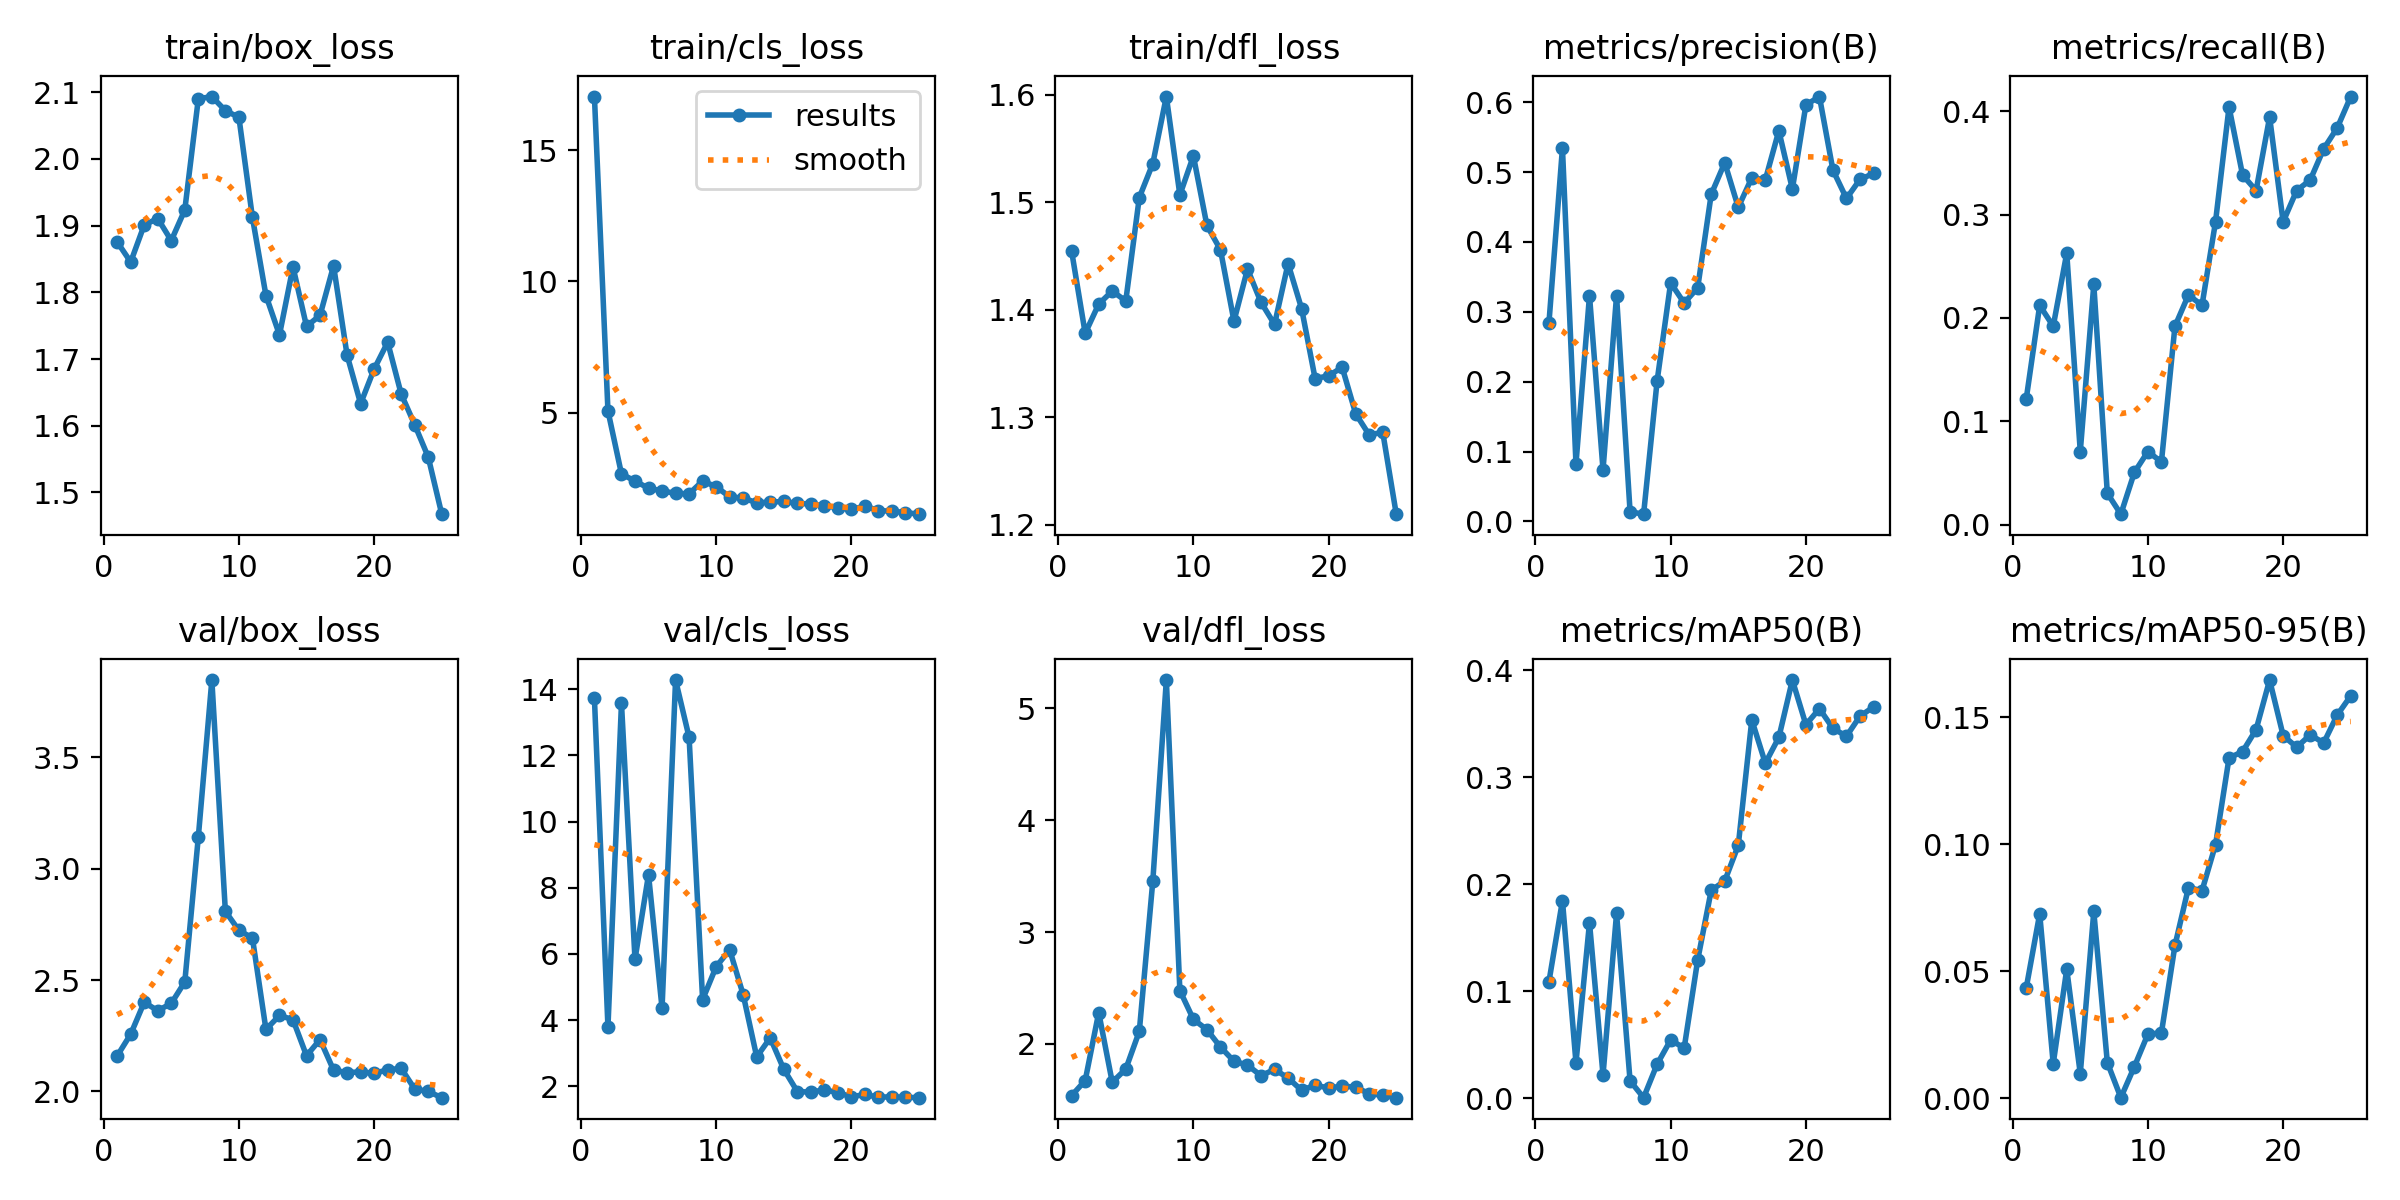

--- Confusion Matrix ---


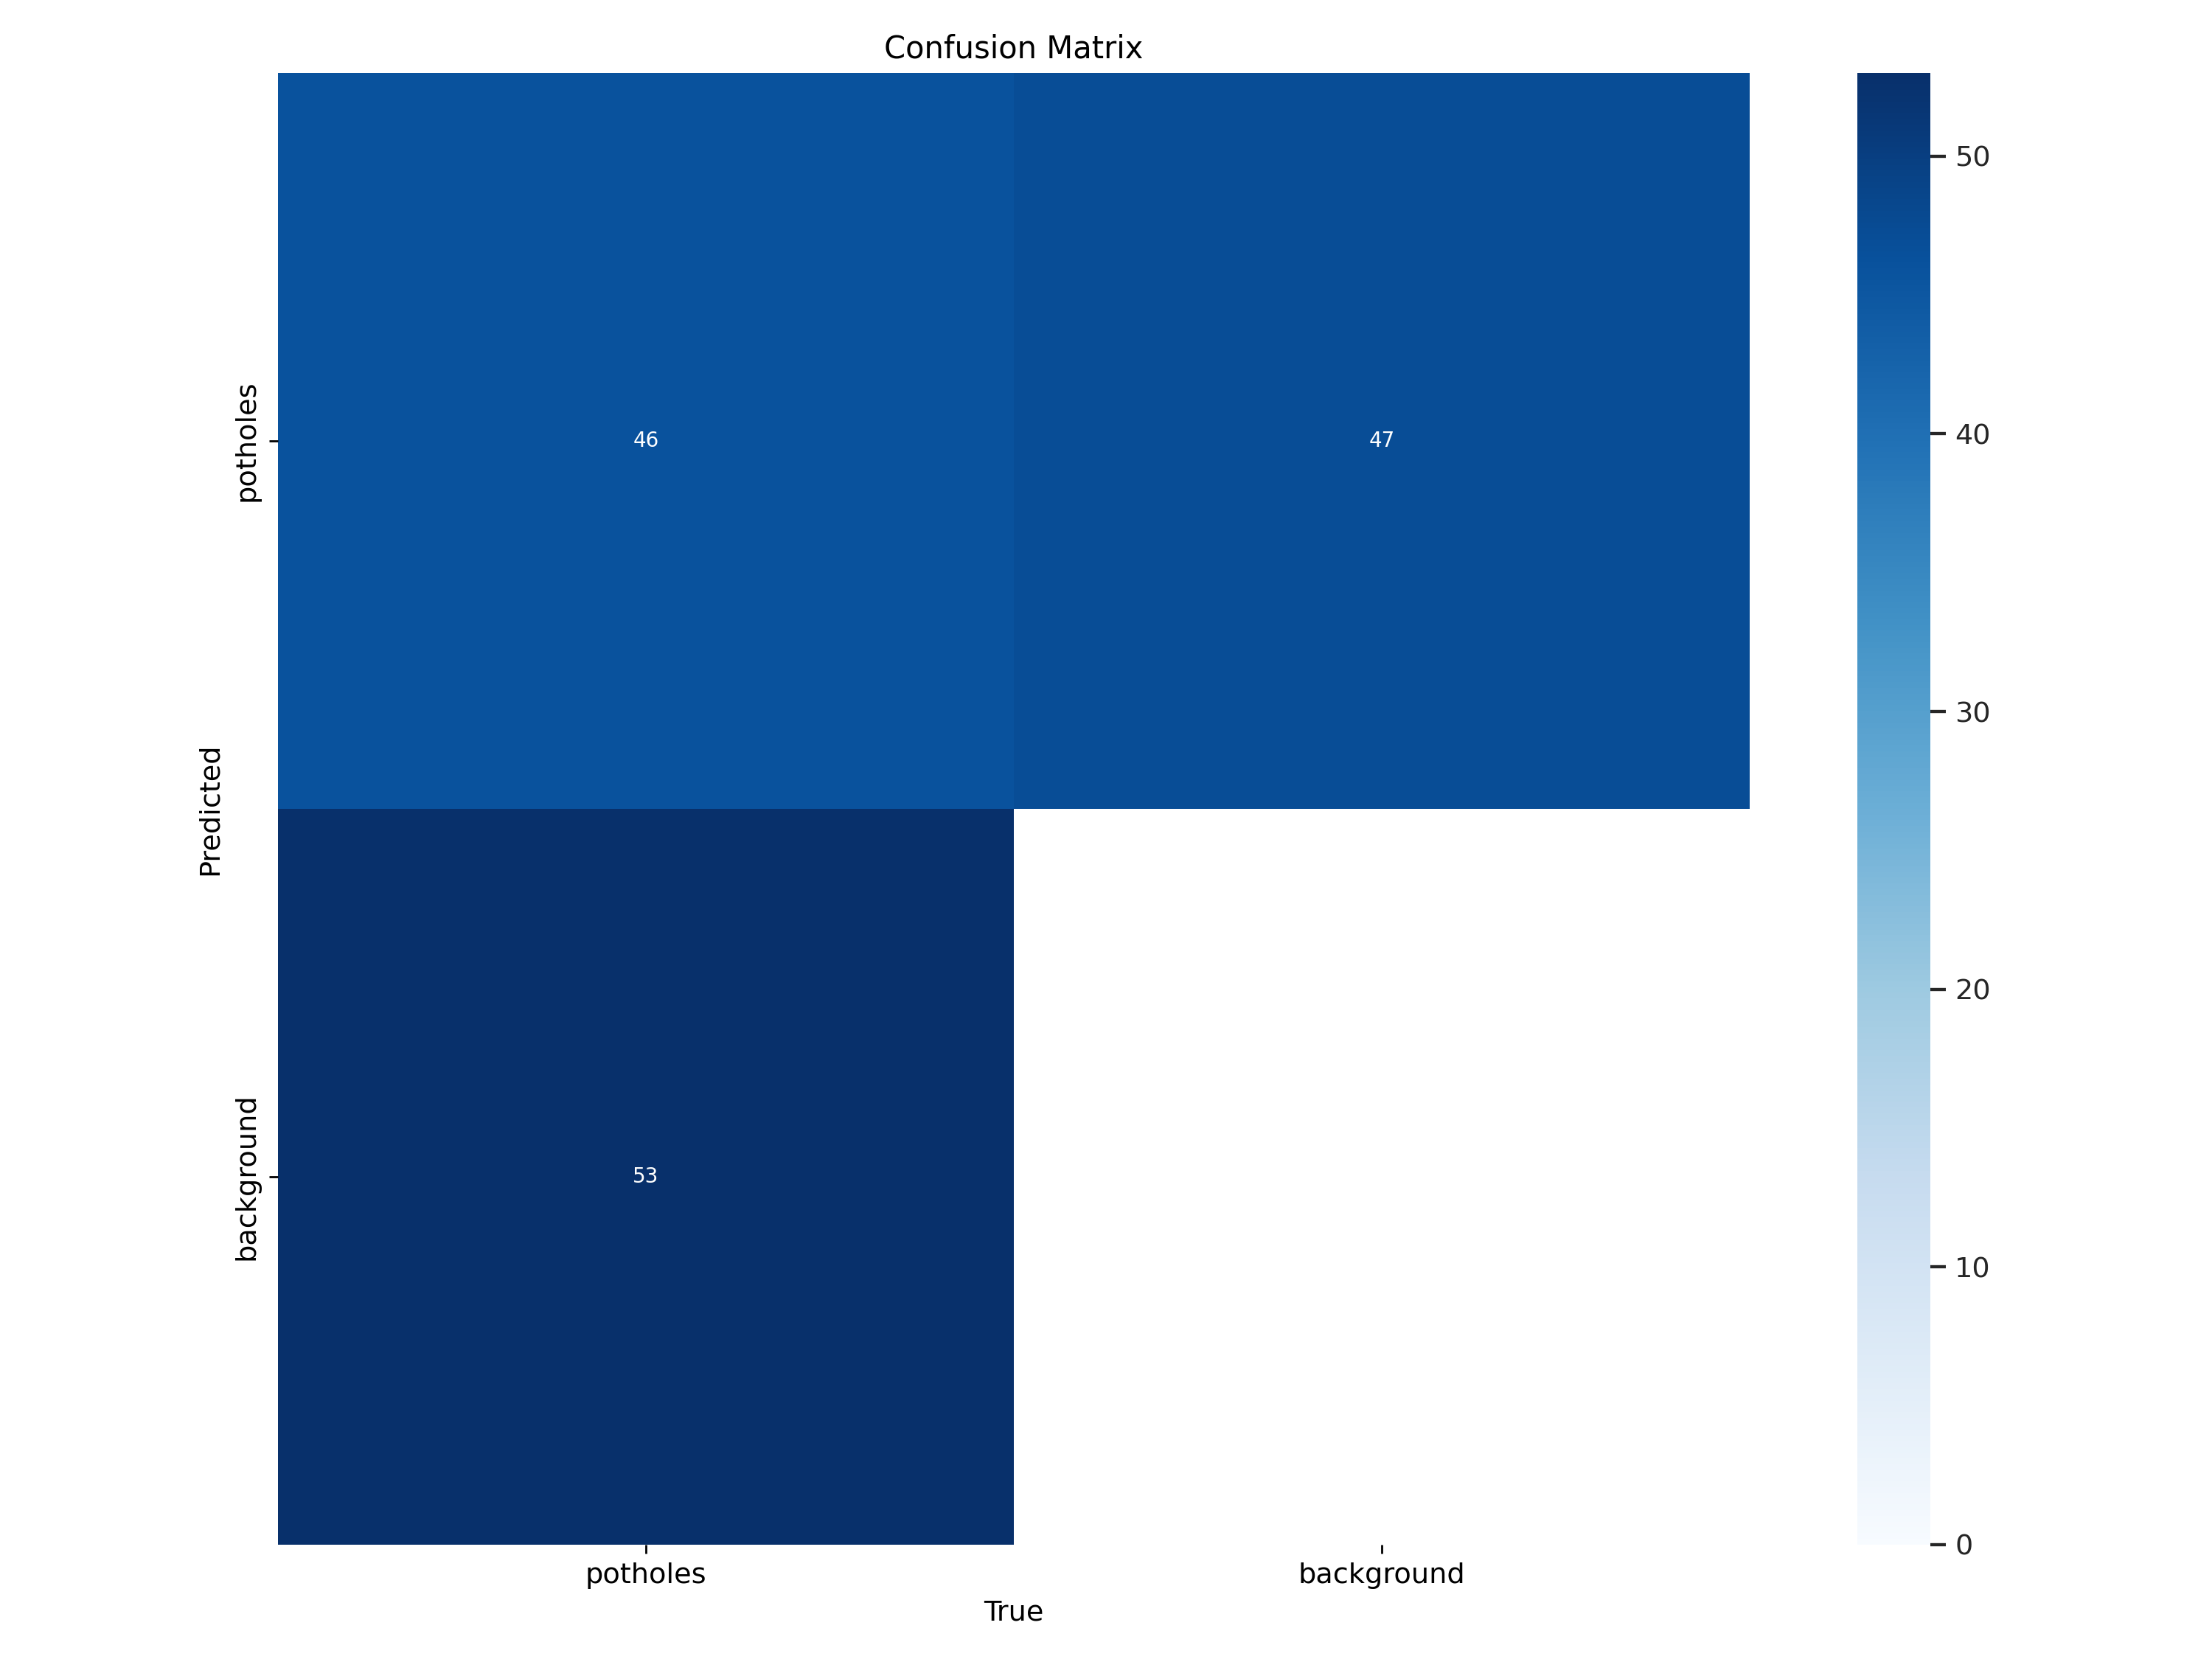

--- Validation Predictions (Labels + Confidence Scores) ---


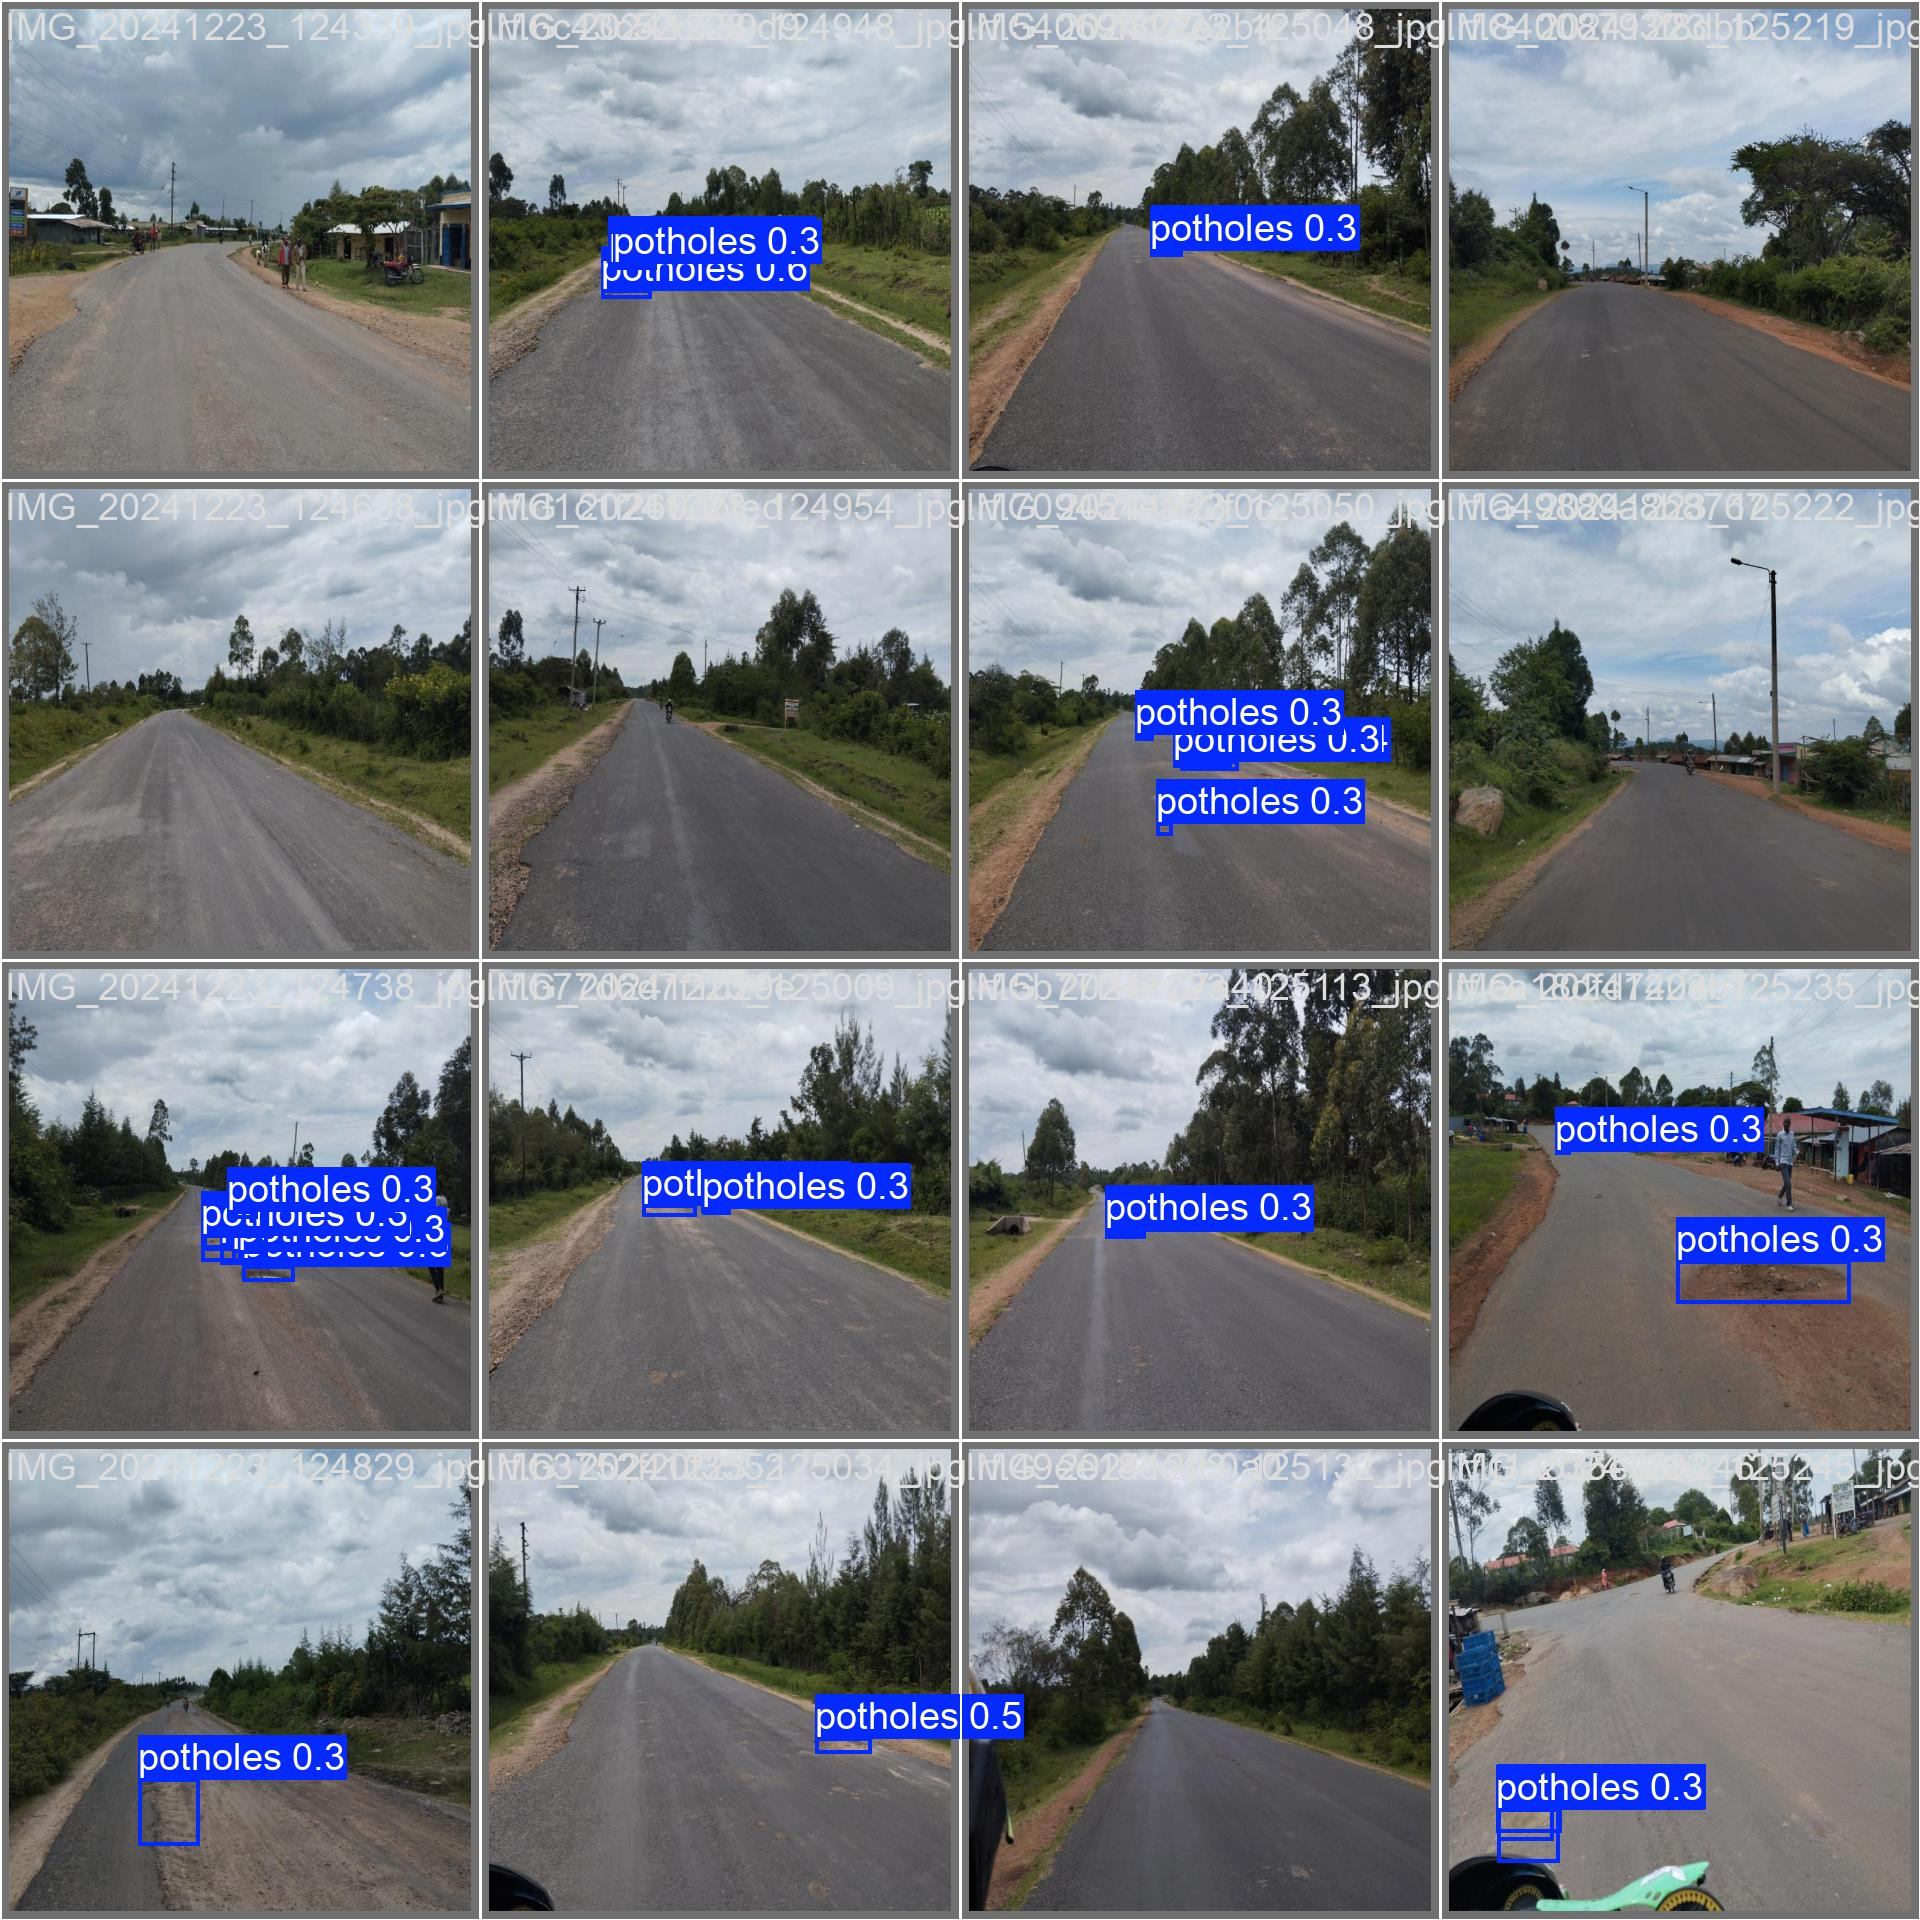

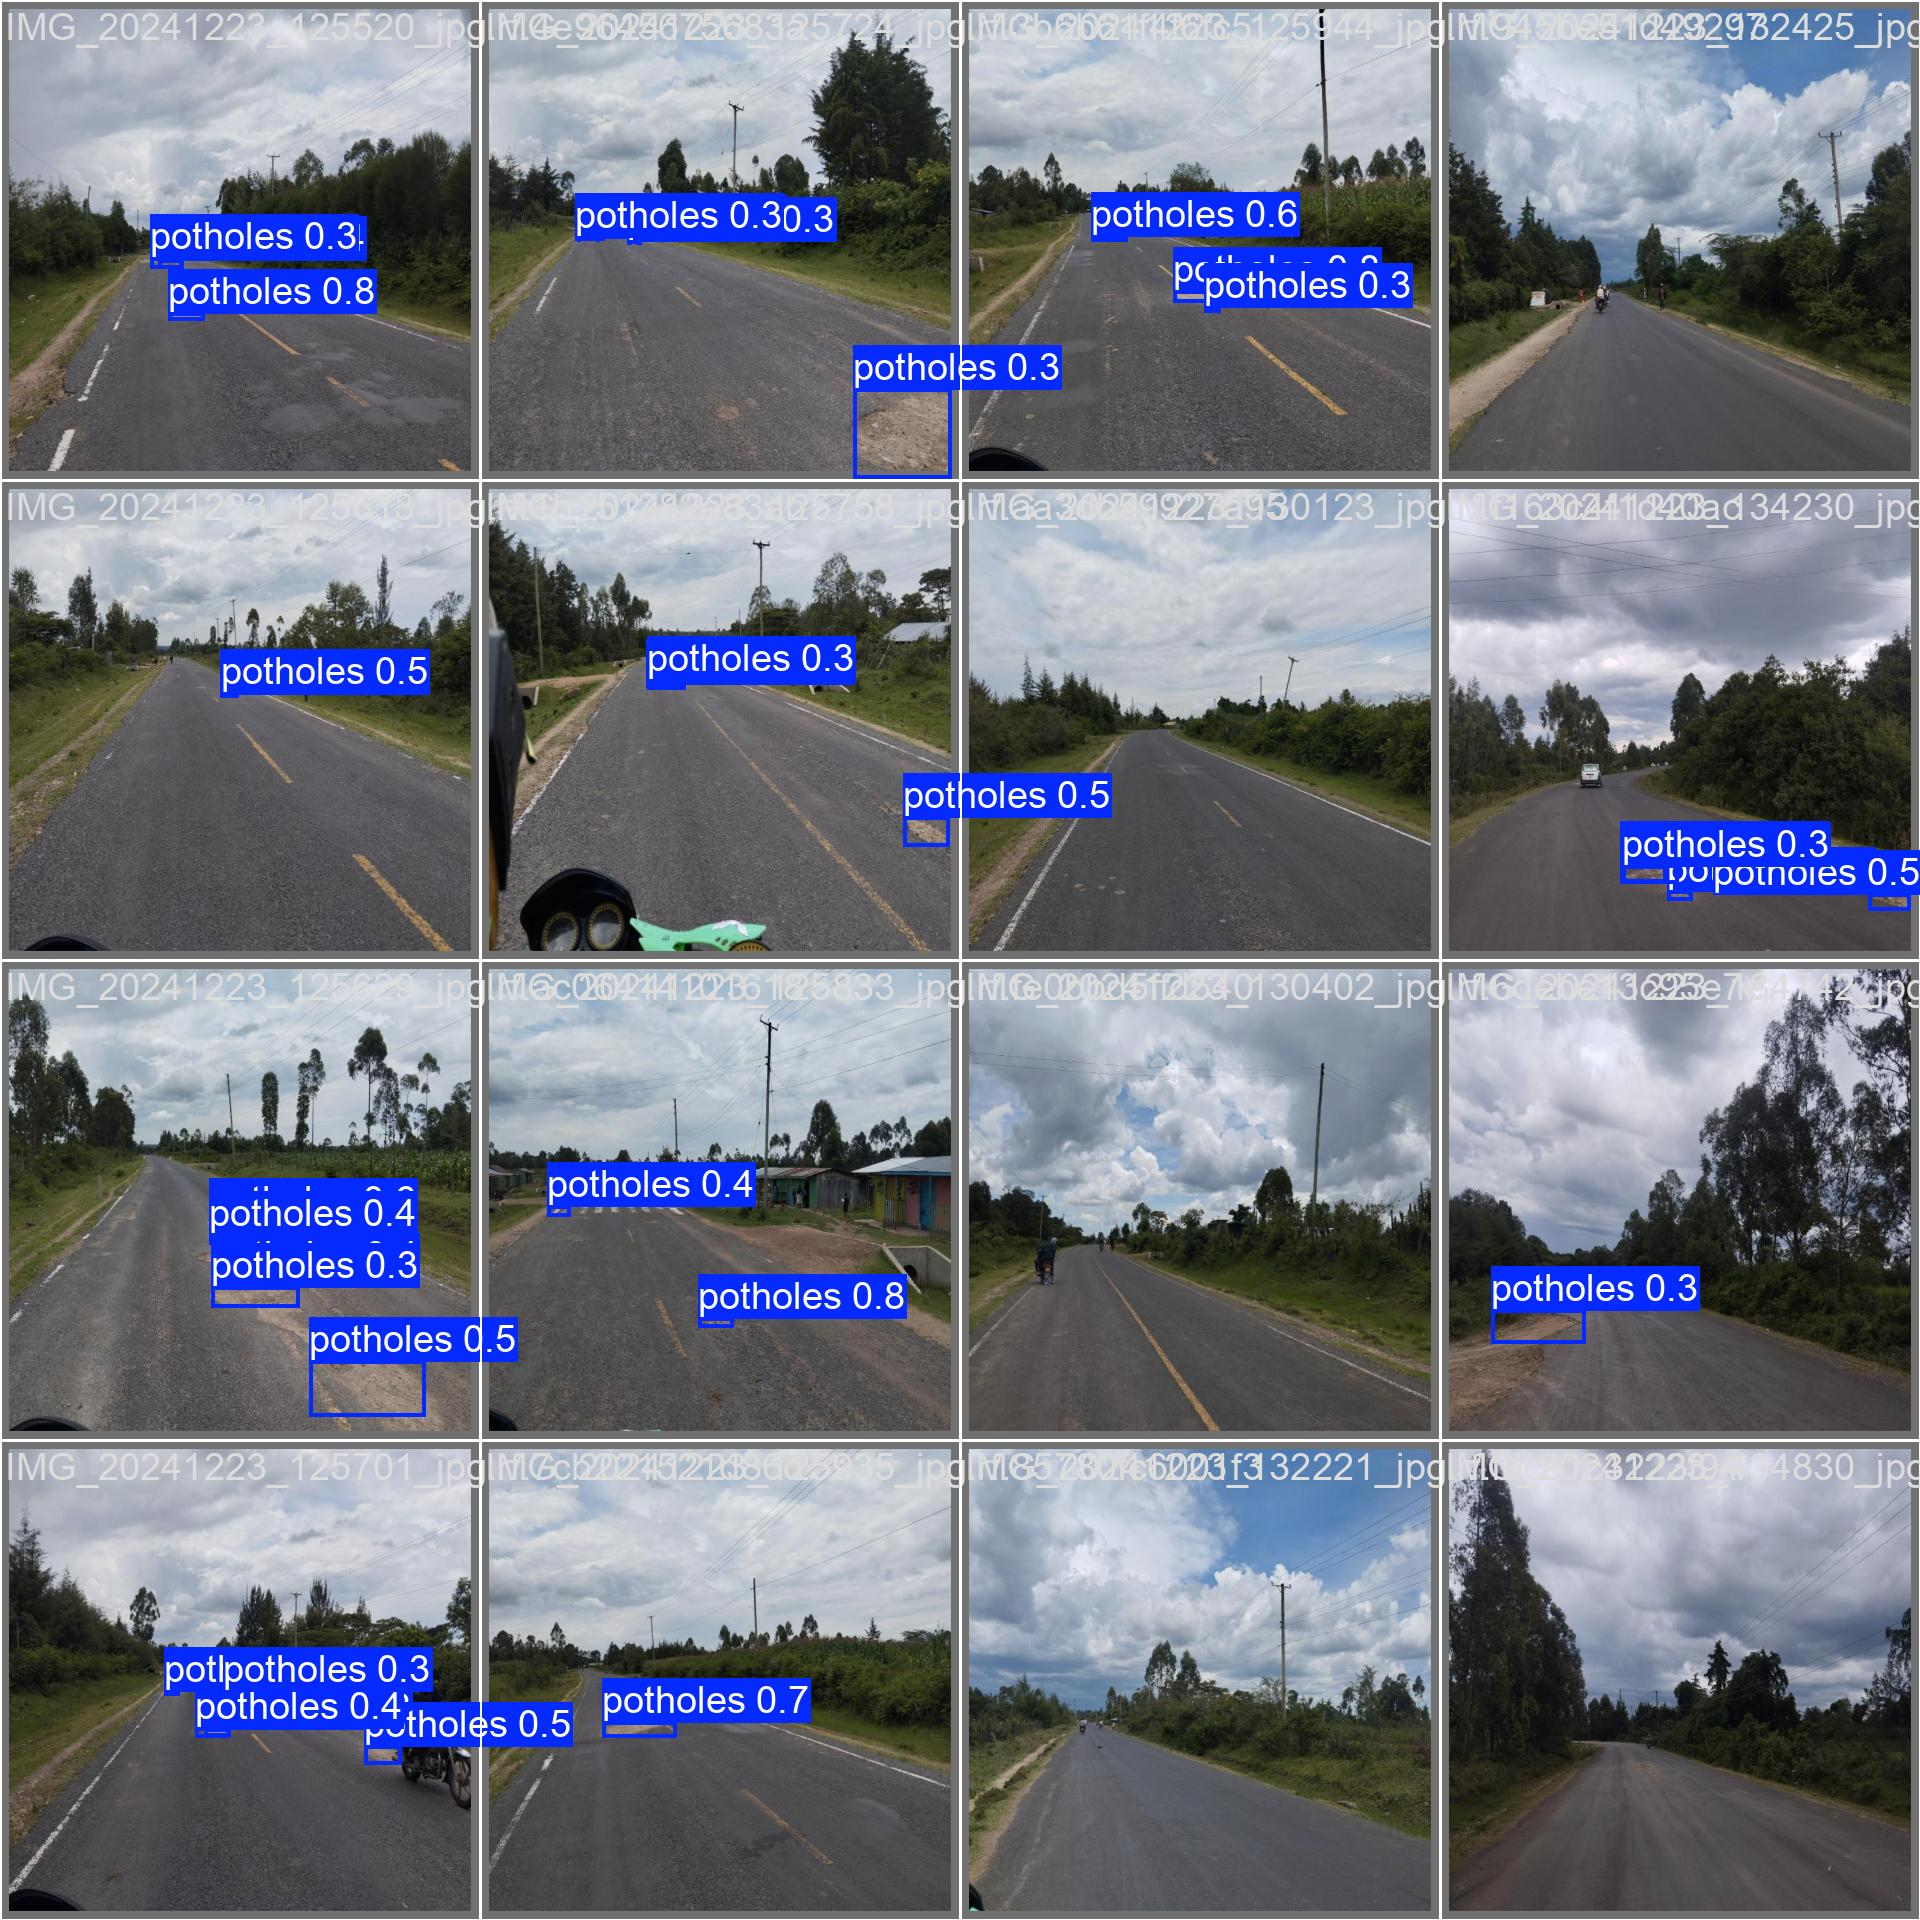

In [8]:
import os
from IPython.display import display, Image

# The training run was saved to 'train2' based on your previous output
results_dir = 'runs/detect/train2'

if os.path.exists(results_dir):
    print("Displaying training and validation results with confidence scores...")

    # 1. Display results plot (loss and metrics over epochs)
    if os.path.exists(f'{results_dir}/results.png'):
        print("--- Training Metrics ---")
        display(Image(filename=f'{results_dir}/results.png', width=800))

    # 2. Display confusion matrix
    if os.path.exists(f'{results_dir}/confusion_matrix.png'):
        print("--- Confusion Matrix ---")
        display(Image(filename=f'{results_dir}/confusion_matrix.png', width=600))

    # 3. Display validation predictions
    # YOLOv8 saves these as val_batchX_pred.jpg
    print("--- Validation Predictions ---")
    for i in range(3):
        pred_path = f'{results_dir}/val_batch{i}_pred.jpg'
        if os.path.exists(pred_path):
            display(Image(filename=pred_path, width=800))
else:
    print(f"Directory {results_dir} not found. Please check your runs folder.")

In [6]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 804, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/yolo/model.py", line 23, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 145, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 285, in _load
    self.model, self.ckpt = attempt_load_one_weight(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py", line 906, in attempt_load_one_weight
    ckpt, weight = torch_safe_load(weight)  # load ckpt
     

---

## Phase 2: Assess - Data Quality Assessment

The second phase involves understanding data quality and characteristics without preconceived questions.

### Data Quality Visualization

---

## Phase 3: Address - Question Answering

The third phase involves answering specific questions using the assessed data, including modeling and visualization.

### Analysis Results Visualization

---

## Next Steps: Customizing Your Analysis

### 1. Update Configuration
Edit `fynesse/defaults.yml` to point to your data sources:

### 2. Implement Your Data Access
Modify `fynesse/access.py` to load your specific data:

### 3. Add Data Assessment Logic
Enhance `fynesse/assess.py` with your quality checks:

### 4. Implement Analysis Functions
Customize `fynesse/address.py` for your specific questions: